# Climate Physical Risk — Flood Risk Model for Consumer Credit Portfolios (Thailand)

**Portfolios:** Mortgage · Business Loan · Auto (Hire-Purchase)
**Framework:** `Physical Risk = Hazard × Exposure × Vulnerability` → credit-risk translation (PD/LGD/EL) → geographic risk mapping
**Author:** Credit Risk Modeling / Data Science
**Run date:** generated at execution time

---

## 1. Objective

Quantify flood (climate physical) risk for a Thai consumer credit portfolio and translate it into
credit-risk metrics that a risk committee can act on:

1. **Flood Hazard Model** — a tambon-level (sub-district, ~7,400 areas) annual flood probability and severity
   index, built from 5+ years of historical flood events, a 30-issue rolling 6-month flood forecast, and
   province-level rainfall forecasts. Validated out-of-sample style against realized 2024 floods.
2. **Portfolio Exposure** — loan-level exposure mapped to tambon geocode. *(A synthetic portfolio is generated
   here as a stand-in — replace §6 with the real loan tape keyed on `GEOCODE`.)*
3. **Vulnerability → Credit Translation** — product-specific damage matrices convert hazard into stressed
   PD/LGD and climate-adjusted Expected Loss under Baseline / Adverse / Severe scenarios.
4. **Risk Mapping** — interactive and static maps of hazard and portfolio EL concentration using Thailand
   tambon centroids (LATLONG).

## 2. Data inventory (IECC folder)

| Source | Granularity | Period | Role |
|---|---|---|---|
| `Flood Forecast 6 month/` (30 files) | Tambon × month | issues 2024-01 … 2026-06 | Forward-looking hazard signal |
| `Flood Historical Data/gd027_flood_stat25xx` | Village/tambon (2563–2567), district (2562), province (2568) | BE 2562–2568 (2019–2025) | Realized flood frequency & severity |
| `Rain Forecast 6 month/` (3 files) | Province × month | 2024–2026 | Rainfall covariate |
| `Flood Forecast 6 month/metadata.xlsx` | Tambon | — | Names, province/region, Thai-name match keys |
| `CodeTAMBON.xlsx` | Tambon centroid | — | Risk mapping coordinates |

**Known data quirks handled below:** forecast files key on `TAMBON_IDN` except 2024-01 (`GEOCODE`);
flood class relabelled mid-series (`inundation` → `flood risk`); historical files change schema every year;
2567 file repeats Thai headers in the first data row; 2568 is a province summary only.

In [1]:
import glob
import json
import re
import warnings
from datetime import datetime
from pathlib import Path

import folium
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import roc_auc_score

warnings.filterwarnings("ignore", category=UserWarning)
pd.set_option("display.float_format", lambda x: f"{x:,.3f}")

IECC = Path("/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/IECC")
FORECAST_DIR = IECC / "Flood Forecast 6 month"
HIST_DIR = IECC / "Flood Historical Data"
RAIN_DIR = IECC / "Rain Forecast 6 month"
LATLONG_PATH = IECC / "CodeTAMBON.xlsx"

PROJECT_DIR = Path("/Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY")
TIMESTAMP = datetime.now().strftime("%Y%m%d_%H%M%S")
OUT_DIR = PROJECT_DIR / "output" / f"risk_model_{TIMESTAMP}"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEED = 42
rng = np.random.default_rng(SEED)

# BE years with usable tambon-level event records (2563-2565 name-matched, 2566-2567 coded)
OBS_YEARS_TAMBON = [2563, 2564, 2565, 2566, 2567]

def normalize_geocode(s: pd.Series) -> pd.Series:
    """Join keys as clean strings (Excel float artifacts like '320101.0' break joins)."""
    return s.astype(str).str.strip().str.replace(r"\.0$", "", regex=True)

def norm_thai(s) -> str:
    """Normalize Thai admin names for cross-file matching (strip prefixes & whitespace)."""
    s = str(s).strip()
    s = re.sub(r"^(ต\.|อ\.|จ\.|ตำบล|อำเภอ|จังหวัด|เขต|แขวง|กิ่งอำเภอ|กิ่ง อ\.)\s*", "", s)
    return re.sub(r"\s+", "", s)

print("Output directory:", OUT_DIR)

ModuleNotFoundError: No module named 'folium'

## 3. Reference data — tambon master, centroids

`metadata.xlsx` is the tambon master (7,387 areas). `CodeTAMBON.xlsx` provides centroids
(duplicates averaged). A normalized Thai-name key (`province|district|subdistrict`) is built for
matching historical files that carry names but no geocodes.

In [ ]:
md = pd.read_excel(FORECAST_DIR / "metadata.xlsx")
md["GEOCODE"] = normalize_geocode(md["GEOCODE"])
md["PROV_CODE"] = md["PROV_CODE.x"].astype(int)
md["match_key"] = (md["PROV_T"].map(norm_thai) + "|" + md["AMPHOE_T"].map(norm_thai)
                   + "|" + md["TAMBON_T"].map(norm_thai))
md = md.drop_duplicates("GEOCODE")

tambon_per_prov = md.groupby("PROV_CODE")["GEOCODE"].nunique().rename("N_TAMBON")
prov_names = md.drop_duplicates("PROV_CODE").set_index("PROV_CODE")[["PROV_T", "PROV_E", "REGION_E"]]
prov_lookup = {norm_thai(v): k for k, v in prov_names["PROV_T"].items()}

ll = pd.read_excel(LATLONG_PATH)
ll["GEOCODE"] = normalize_geocode(ll["TAMBON_IDN"])
cen = ll.groupby("GEOCODE")[["LATITUDE_CENTER_TAMBON", "LONGITUDE_CENTER_TAMBON"]].mean().reset_index()

print(f"tambon master : {len(md):,} tambons, {md['PROV_CODE'].nunique()} provinces")
print(f"centroids     : {len(cen):,} tambons with coordinates "
      f"({len(set(md['GEOCODE']) - set(cen['GEOCODE']))} without)")

NameError: name 'pd' is not defined

## 4. Hazard input A — historical flood events (BE 2562–2568 / 2019–2025)

Every yearly file has a different schema. Harmonization strategy:

| BE year | Sheet | Granularity | Join method |
|---|---|---|---|
| 2562 (2019) | `flood2562cut` | District summary | Province name → province prior only |
| 2563 (2020) | `รายชื่อหมู่บ้าน` | Village | Thai-name match (~99%) |
| 2564 (2021) | `รายชื่อหมู่บ้าน` | Village | Thai-name match (~99%) |
| 2565 (2022) | `รายหมู่ที่` | Village | Thai-name match (~99%) |
| 2566 (2023) | `พื้นที่เกิด` (header row 3) | Village | Tambon code (direct) |
| 2567 (2024) | `อุทกภัย67-รายการพื้นที่เกิด (2)` | Village | Tambon code (direct) |
| 2568 (2025) | `อุทกภัย68` | Province summary | Province name → province prior only |

Output: a standardized **tambon-year panel** — was the tambon flooded that year, how many event dates,
and impact severity (affected households / housing damaged, available 2566–2567).

In [ ]:
def load_hist_coded(path, sheet, header_row, code_col, date_col, hh_col, house_col):
    """Years that carry a 6-digit tambon code. Drops the Thai duplicate-header row if present."""
    df = pd.read_excel(path, sheet_name=sheet, header=header_row)
    if not pd.api.types.is_numeric_dtype(df[code_col]):
        if pd.to_numeric(pd.Series([df.iloc[0][code_col]]), errors="coerce").isna().all():
            df = df.iloc[1:]
    out = pd.DataFrame({
        "GEOCODE": normalize_geocode(
            pd.to_numeric(df[code_col], errors="coerce").astype("Int64").astype(str)),
        "EVENT_DATE": pd.to_datetime(df[date_col], errors="coerce"),
        "AFF_HH": pd.to_numeric(df[hh_col], errors="coerce"),
        "HOUSING": pd.to_numeric(df[house_col], errors="coerce"),
    })
    return out[out["GEOCODE"].notna() & (out["GEOCODE"] != "<NA>")]

def load_hist_named(path, sheet, pcol, dcol, tcol, date_col):
    """Years with Thai names only -> match on normalized province|district|subdistrict."""
    df = pd.read_excel(path, sheet_name=sheet).dropna(subset=[tcol])
    key = df[pcol].map(norm_thai) + "|" + df[dcol].map(norm_thai) + "|" + df[tcol].map(norm_thai)
    out = pd.DataFrame({"match_key": key,
                        "EVENT_DATE": pd.to_datetime(df[date_col], errors="coerce"),
                        "AFF_HH": np.nan, "HOUSING": np.nan})
    out = out.merge(md[["match_key", "GEOCODE"]], on="match_key", how="left")
    coverage = out["GEOCODE"].notna().mean()
    return out.dropna(subset=["GEOCODE"])[["GEOCODE", "EVENT_DATE", "AFF_HH", "HOUSING"]], coverage

events = []
e67 = load_hist_coded(HIST_DIR / "gd027_flood_stat2567_final.xlsx",
                      "อุทกภัย67-รายการพื้นที่เกิด (2)", 0, "Sub-district Code",
                      "Disaster Date", "Affected Households", "Housing (Units)")
e67["BE_YEAR"] = 2567
events.append(e67)
print(f"2567: tambon-coded, rows {len(e67):,}")

e66 = load_hist_coded(HIST_DIR / "gd027_flood_stat2566_final.xlsx", "พื้นที่เกิด", 2,
                      "รหัสตำบล", "วันที่เกิดภัย",
                      "ผู้ได้รับผลกระทบ\n(ครัวเรือน)", "ด้านที่อยู่อาศัย\n(หลัง/แห่ง)")
e66["BE_YEAR"] = 2566
events.append(e66)
print(f"2566: tambon-coded, rows {len(e66):,}")

named_specs = {
    2563: ("gd027_flood_stat2563_final.xlsx", "รายชื่อหมู่บ้าน",
           "province", "district", "subdistrict", "Disaster Area Date"),
    2564: ("gd027_flood_stat2564_final.xlsx", "รายชื่อหมู่บ้าน",
           "province", "district", "subdistrict", "Disaster Area Date"),
    2565: ("gd027_flood_stat2565_final.xlsx", "รายหมู่ที่",
           "province", "district", "subdistrict", "Disaster Area Date"),
}
for be, (fn, sheet, p, d, t, dc) in named_specs.items():
    e, cov = load_hist_named(HIST_DIR / fn, sheet, p, d, t, dc)
    e["BE_YEAR"] = be
    events.append(e)
    print(f"{be}: name-matched, coverage {cov:.1%}, rows {len(e):,}")

hist = pd.concat(events, ignore_index=True)
hist = hist[hist["GEOCODE"].isin(set(md["GEOCODE"]))]

# tambon-year panel
ty = hist.groupby(["GEOCODE", "BE_YEAR"]).agg(
    N_RECORDS=("GEOCODE", "size"),
    N_EVENT_DATES=("EVENT_DATE", "nunique"),
    AFF_HH=("AFF_HH", "sum"),
    HOUSING=("HOUSING", "sum"),
).reset_index()
print(f"\nstandardized village-level records : {len(hist):,}")
print(f"tambon-year flooded combinations   : {len(ty):,}")
print(f"tambons flooded at least once      : {ty['GEOCODE'].nunique():,} of {len(md):,}")

NameError: name 'HIST_DIR' is not defined

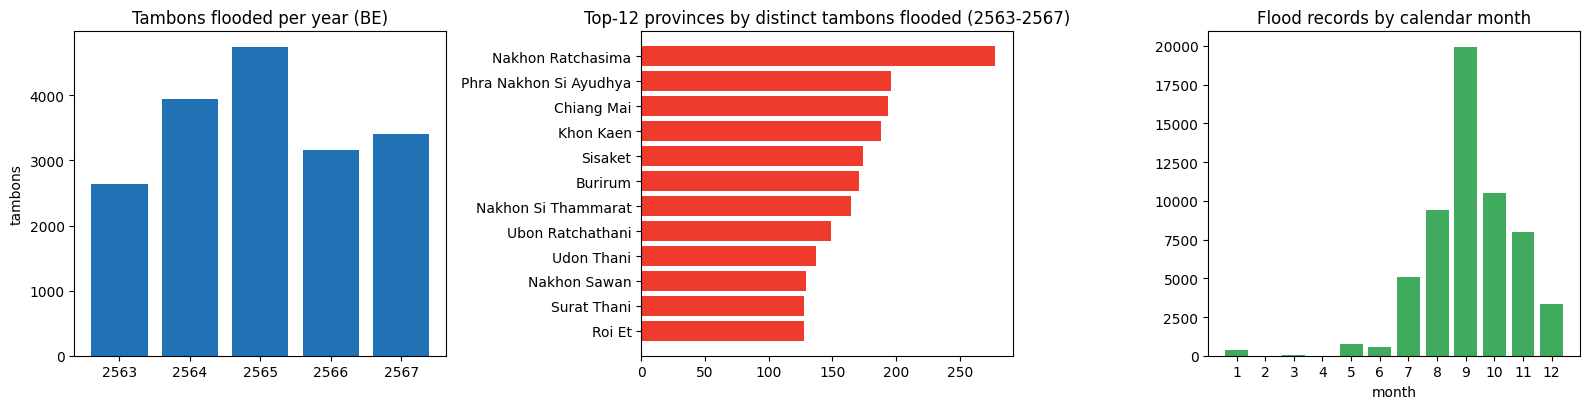

In [ ]:
# EDA: how widespread is flooding each year, and when within the year?
fig, axes = plt.subplots(1, 3, figsize=(16, 4.2))

yearly = ty.groupby("BE_YEAR")["GEOCODE"].nunique()
axes[0].bar(yearly.index.astype(str), yearly.values, color="#2171b5")
axes[0].set_title("Tambons flooded per year (BE)")
axes[0].set_ylabel("tambons")

top_prov = (ty.merge(md[["GEOCODE", "PROV_E"]], on="GEOCODE")
              .groupby("PROV_E")["GEOCODE"].nunique().nlargest(12).sort_values())
axes[1].barh(top_prov.index, top_prov.values, color="#ef3b2c")
axes[1].set_title("Top-12 provinces by distinct tambons flooded (2563-2567)")

months = hist["EVENT_DATE"].dt.month.value_counts().sort_index()
axes[2].bar(months.index, months.values, color="#41ab5d")
axes[2].set_title("Flood records by calendar month")
axes[2].set_xlabel("month")
axes[2].set_xticks(range(1, 13))

fig.tight_layout()
fig.savefig(OUT_DIR / "eda_historical_floods.png", dpi=130, bbox_inches="tight")
plt.show()

## 5. Hazard input B — province priors (credibility smoothing)

Five years of tambon history is short: a tambon with zero recorded events may still sit in a flood-prone
province. For each province-year we compute **the share of the province's tambons flooded**, averaging over
all seven years (2562 and 2568 contribute via their summary counts). This becomes the prior in an
empirical-Bayes style smoothing of tambon frequency:

$$P_{hist}(\text{tambon}) = \frac{n_{\text{years flooded}} + k \cdot \pi_{province}}{n_{\text{years observed}} + k}, \quad k = 2$$

In [ ]:
# province-year share of tambons flooded, from the tambon-level years
tmp = ty.merge(md[["GEOCODE", "PROV_CODE"]], on="GEOCODE")
ps = (tmp.groupby(["PROV_CODE", "BE_YEAR"])["GEOCODE"].nunique()
         .rename("N_TAMBON_FLOODED").reset_index())

# 2562: district-level summary -> sum of affected-subdistrict counts per province
d62 = pd.read_excel(HIST_DIR / "gd027_flood_stat2562_final.xlsx", sheet_name="flood2562cut")
d62["PROV_CODE"] = d62["Province"].map(lambda x: prov_lookup.get(norm_thai(x)))
s62 = (d62.dropna(subset=["PROV_CODE"]).groupby("PROV_CODE")["Subdistrict Count"].sum()
          .reset_index().rename(columns={"Subdistrict Count": "N_TAMBON_FLOODED"}))
s62["BE_YEAR"] = 2562

# 2568: province summary -> affected sub-district counts directly
d68 = pd.read_excel(HIST_DIR / "gd027_flood_stat2568_final.xlsx", sheet_name="อุทกภัย68").iloc[1:]
d68["PROV_CODE"] = d68["Province"].map(lambda x: prov_lookup.get(norm_thai(x)))
d68["N_TAMBON_FLOODED"] = pd.to_numeric(d68["Sub-district"], errors="coerce")
s68 = d68.dropna(subset=["PROV_CODE", "N_TAMBON_FLOODED"])[["PROV_CODE", "N_TAMBON_FLOODED"]]
s68["BE_YEAR"] = 2568

ps = pd.concat([ps, s62, s68], ignore_index=True)
ps["N_TAMBON_FLOODED"] = pd.to_numeric(ps["N_TAMBON_FLOODED"], errors="coerce")
ps = ps.dropna(subset=["N_TAMBON_FLOODED"]).merge(tambon_per_prov, on="PROV_CODE")
ps["SHARE"] = (ps["N_TAMBON_FLOODED"] / ps["N_TAMBON"]).clip(0, 1).astype(float)

prov_prior = ps.groupby("PROV_CODE")["SHARE"].mean().rename("PROV_PRIOR")
print("province prior (avg share of tambons flooded per year):")
print(prov_prior.describe().round(3))
print("\nmost flood-prone provinces:")
print(prov_prior.nlargest(8).rename(index=prov_names["PROV_E"]).round(3))

province prior (avg share of tambons flooded per year):
count   77.000
mean     0.512
std      0.168
min      0.134
25%      0.402
50%      0.497
75%      0.622
max      0.922
Name: PROV_PRIOR, dtype: float64

most flood-prone provinces:
PROV_CODE
Narathiwat       0.922
Tak              0.821
Mae Hong Son     0.819
Amnaj Charoen    0.811
Phatthalung      0.798
Yala             0.776
Sukhothai        0.776
Nakhon Prathom   0.733
Name: PROV_PRIOR, dtype: float64


## 6. Hazard input C — forward-looking 6-month flood forecast (30 rolling issues)

Each monthly issue classifies every tambon × target-month as `norisk` / `flashflood` / `flood`.
We compute a **forecast propensity** per tambon = mean flag weight across all forecast records
(flood = 1.0, flashflood = 0.5). A 2024-only slice (issues in 2024 targeting 2024) is kept aside as
the *predictor* in the validation model of §8 — so validation uses only information available in-year.

forecast records : 1,329,840 across 30 issues
tambons with any flood/flashflood flag: 6,635 of 7,387


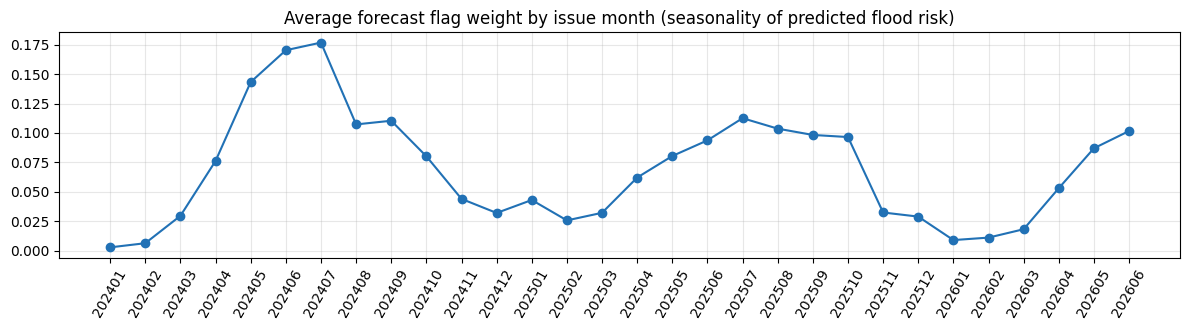

In [ ]:
KEEP = ["GEOCODE", "TYPE_E", "YEAR", "MONTH"]
RISK_MAP = {"norisk": 0, "flashflood": 1, "inundation": 2, "flood risk": 2}

frames = []
for f in sorted(FORECAST_DIR.glob("*FloodForecast_6month.xlsx")):
    if f.name.startswith("~$"):
        continue
    issue = re.match(r"(\d{6})", f.name).group(1)
    raw = pd.read_excel(f)
    if "GEOCODE" not in raw.columns:          # 29 of 30 files key on TAMBON_IDN
        raw["GEOCODE"] = raw["TAMBON_IDN"]
    df = raw[KEEP].copy()
    df["ISSUE"] = issue
    frames.append(df)

fc = pd.concat(frames, ignore_index=True)
fc["GEOCODE"] = normalize_geocode(fc["GEOCODE"])
fc["TYPE_E"] = fc["TYPE_E"].astype(str).str.strip().str.lower()
unknown = set(fc["TYPE_E"].unique()) - set(RISK_MAP)
assert not unknown, f"unexpected TYPE_E values: {unknown}"
fc["RISK_CODE"] = fc["TYPE_E"].map(RISK_MAP).astype("int8")
fc["W"] = fc["RISK_CODE"].map({0: 0.0, 1: 0.5, 2: 1.0})

fprop = fc.groupby("GEOCODE").agg(FC_PROP=("W", "mean"), FC_MAX=("RISK_CODE", "max")).reset_index()
fc24 = fc[(fc["ISSUE"].str[:4] == "2024") & (fc["YEAR"] == 2024)]
fprop24 = fc24.groupby("GEOCODE")["W"].mean().rename("FC_PROP_2024").reset_index()

print(f"forecast records : {len(fc):,} across {fc['ISSUE'].nunique()} issues")
print(f"tambons with any flood/flashflood flag: {(fprop['FC_PROP'] > 0).sum():,} of {len(fprop):,}")

flag_share = fc.groupby("ISSUE")["W"].mean()
fig, ax = plt.subplots(figsize=(12, 3.4))
ax.plot(flag_share.index, flag_share.values, marker="o", color="#2171b5")
ax.set_title("Average forecast flag weight by issue month (seasonality of predicted flood risk)")
ax.tick_params(axis="x", rotation=60)
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(OUT_DIR / "eda_forecast_seasonality.png", dpi=130, bbox_inches="tight")
plt.show()

## 7. Hazard input D — province rainfall forecast (2024–2026)

Used two ways: total 2024 rainfall as a validation-model covariate, and the forward window
(2026) as the rainfall input when scoring forward-looking flood probability.

In [ ]:
rain = pd.concat([pd.read_csv(f) for f in sorted(glob.glob(str(RAIN_DIR / "*.csv")))],
                 ignore_index=True)
if "Rainfall.mm." in rain.columns:            # column name differs across files -> coalesce
    rain["Rainfall"] = rain["Rainfall"].fillna(rain["Rainfall.mm."])

rain24 = rain[rain["Forecast_Year"] == 2024].groupby("Province_ID")["Rainfall"].sum().rename("RAIN_2024")
rain_fwd = rain[rain["Forecast_Year"] >= 2026].groupby("Province_ID")["Rainfall"].sum().rename("RAIN_FWD")
rain_idx = (pd.concat([rain24, rain_fwd], axis=1).reset_index()
              .rename(columns={"Province_ID": "PROV_CODE"}))
print(f"rainfall: {len(rain):,} province-month rows, {rain_idx.shape[0]} provinces")
rain_idx.describe().round(0)

rainfall: 13,398 province-month rows, 77 provinces


,PROV_CODE,RAIN_2024,RAIN_FWD
count,77.000,77.000,77.000
mean,51.000,"8,681.000","5,549.000"
std,25.000,"3,662.000","1,936.000"
min,10.000,"5,104.000","2,964.000"
25%,31.000,"6,298.000","4,484.000"
50%,50.000,"7,258.000","4,986.000"
75%,72.000,"8,659.000","5,748.000"
max,96.000,"19,820.000","13,035.000"


## 8. Hazard model — calibrated annual flood probability + severity

**Step 1 — smoothed historical frequency** (§5 formula).

**Step 2 — validation:** a logistic regression predicts *realized 2024 flooding* (from the 2567 file) using
only signals available in 2024: the 2024 forecast propensity, pre-2024 flood history (2563–2566), the
province prior, and 2024 rainfall. AUC and a decile calibration table check that the signals rank and scale
correctly — this is the evidence that the forecast product adds real information.

**Step 3 — forward scoring:** the fitted model is re-scored with forward-looking inputs (full forecast
propensity, full 5-year history, forward rainfall) → **`P_EVENT`** = probability that a tambon records ≥1
flood event in a 1-year horizon.

**Step 4 — severity:** mean affected households per flooded year (2566–2567 impact data), square-root scaled
to a 0–1 **`SEV_IDX`** (median-imputed for flooded tambons without impact data).

**Step 5 — hazard score & grade:** `SCORE = 100 · P_EVENT · (0.5 + 0.5 · SEV_IDX)`, graded
G1 < 5, G2 5–15, G3 15–30, G4 30–50, G5 ≥ 50.

In [ ]:
panel = md[["GEOCODE", "PROV_CODE", "PROV_E", "REGION_E", "TAMBON_E", "AMPHOE_E"]].copy()

flooded_years = ty.groupby("GEOCODE")["BE_YEAR"].nunique().rename("N_YEARS_FLOODED")
panel = panel.merge(flooded_years, on="GEOCODE", how="left").fillna({"N_YEARS_FLOODED": 0})
panel = panel.merge(prov_prior, on="PROV_CODE", how="left")
panel["PROV_PRIOR"] = panel["PROV_PRIOR"].fillna(prov_prior.mean())

K = 2.0
panel["P_HIST"] = (panel["N_YEARS_FLOODED"] + K * panel["PROV_PRIOR"]) / (len(OBS_YEARS_TAMBON) + K)

panel = panel.merge(fprop, on="GEOCODE", how="left").fillna({"FC_PROP": 0, "FC_MAX": 0})
panel = panel.merge(fprop24, on="GEOCODE", how="left").fillna({"FC_PROP_2024": 0})
panel = panel.merge(rain_idx, on="PROV_CODE", how="left")
for c in ["RAIN_2024", "RAIN_FWD"]:
    panel[c] = panel[c].fillna(panel[c].median())

pre = ty[ty["BE_YEAR"] <= 2566].groupby("GEOCODE")["BE_YEAR"].nunique().rename("N_YEARS_PRE")
panel = panel.merge(pre, on="GEOCODE", how="left").fillna({"N_YEARS_PRE": 0})
panel["FLOOD_2024"] = panel["GEOCODE"].isin(set(ty.loc[ty["BE_YEAR"] == 2567, "GEOCODE"])).astype(int)

FEATURES = ["FC_PROP_2024", "N_YEARS_PRE", "PROV_PRIOR", "RAIN_2024"]
X = panel[FEATURES].copy()
X["RAIN_2024"] = X["RAIN_2024"] / 1000.0      # scale mm -> meters for coefficient readability
y = panel["FLOOD_2024"]

model = LogisticRegression(max_iter=2000)
model.fit(X, y)
p_hat = model.predict_proba(X)[:, 1]

print(f"2024 realized flood base rate : {y.mean():.1%} of tambons")
print(f"AUC                           : {roc_auc_score(y, p_hat):.3f}")
print("\ncoefficients (log-odds):")
for f_, c_ in zip(FEATURES, model.coef_[0]):
    print(f"  {f_:<14s} {c_:+.3f}   (odds ratio {np.exp(c_):.2f})")

calib = (pd.DataFrame({"pred": p_hat, "actual": y})
           .assign(decile=lambda d: pd.qcut(d["pred"], 10, labels=False) + 1)
           .groupby("decile").agg(pred_mean=("pred", "mean"), actual_rate=("actual", "mean"),
                                  n=("actual", "size")))
print("\ncalibration by predicted-probability decile:")
print(calib.round(3).to_string())

2024 realized flood base rate : 46.1% of tambons
AUC                           : 0.811

coefficients (log-odds):
  FC_PROP_2024   +3.953   (odds ratio 52.08)
  N_YEARS_PRE    +0.235   (odds ratio 1.27)
  PROV_PRIOR     +4.953   (odds ratio 141.55)
  RAIN_2024      +0.134   (odds ratio 1.14)

calibration by predicted-probability decile:
        pred_mean  actual_rate    n
decile                             
1           0.093        0.042  756
2           0.157        0.150  722
3           0.218        0.247  744
4           0.304        0.322  736
5           0.388        0.394  736
6           0.482        0.501  741
7           0.589        0.615  736
8           0.693        0.662  743
9           0.786        0.781  735
10          0.904        0.901  738


hazard grade distribution (tambons):
  G1 Very Low     622  (8.4%)
  G2 Low        2,102  (28.5%)
  G3 Moderate   2,343  (31.7%)
  G4 High       1,900  (25.7%)
  G5 Very High    420  (5.7%)


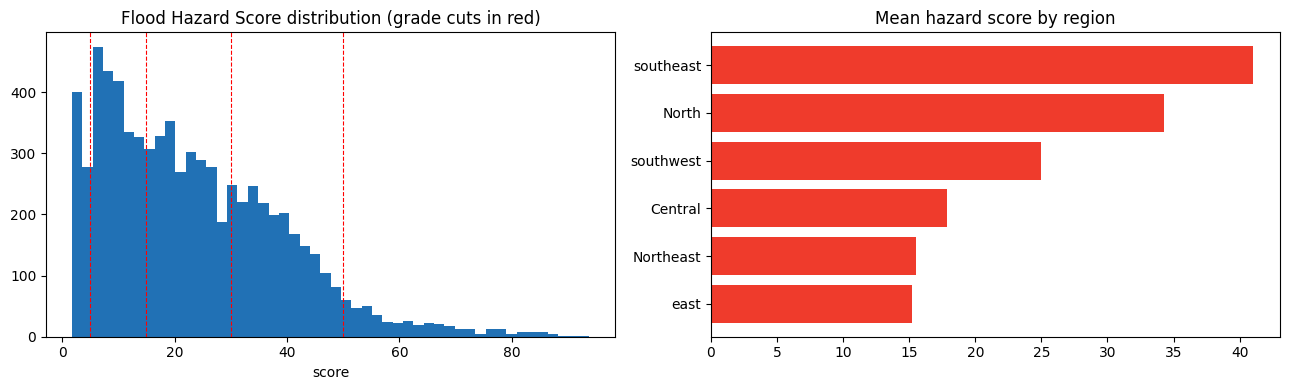


top-15 highest-hazard tambons:
GEOCODE     TAMBON_E                   AMPHOE_E      PROV_E  P_EVENT  SEV_IDX  HAZARD_SCORE  HAZARD_GRADE
 960501  Tanyong Mat           Ra-ngae District  Narathiwat    0.940    0.995        93.765             5
 960102       Lamphu Mueang Narathiwat District  Narathiwat    0.932    0.958        91.299             5
 960703    Si Sakhon         Si Sakhon District  Narathiwat    0.903    0.988        89.713             5
 960508  Ba-Ngo Sato           Ra-ngae District  Narathiwat    0.934    0.880        87.790             5
 960502 Tanyong Limo           Ra-ngae District  Narathiwat    0.940    0.847        86.832             5
 640702   Nai Mueang       Sawankhalok District   Sukhothai    0.868    1.000        86.823             5
 960507       Kalisa           Ra-ngae District  Narathiwat    0.910    0.905        86.713             5
 960103  Manang Tayo Mueang Narathiwat District  Narathiwat    0.932    0.855        86.499             5
 930607      D

In [ ]:
# forward scoring: same fitted model, forward-looking inputs
X_fwd = pd.DataFrame({
    "FC_PROP_2024": panel["FC_PROP"],          # propensity over all 30 issues
    "N_YEARS_PRE": panel["N_YEARS_FLOODED"],   # full 5-year history
    "PROV_PRIOR": panel["PROV_PRIOR"],
    "RAIN_2024": panel["RAIN_FWD"] / 1000.0,   # forward rainfall window
})[FEATURES]
panel["P_EVENT"] = model.predict_proba(X_fwd)[:, 1]

# severity: mean affected households per flooded year (impact data exists for 2566-2567)
sev = ty[ty["AFF_HH"] > 0].groupby("GEOCODE")["AFF_HH"].mean().rename("AFF_HH_MEAN")
panel = panel.merge(sev, on="GEOCODE", how="left")
sev_med = panel.loc[panel["N_YEARS_FLOODED"] > 0, "AFF_HH_MEAN"].median()
panel["AFF_HH_MEAN"] = np.where(panel["N_YEARS_FLOODED"] > 0,
                                panel["AFF_HH_MEAN"].fillna(sev_med), 0.0)
p99 = panel["AFF_HH_MEAN"].quantile(0.99)
panel["SEV_IDX"] = np.sqrt(panel["AFF_HH_MEAN"].clip(0, p99) / p99)   # dampen heavy skew

panel["HAZARD_SCORE"] = 100 * panel["P_EVENT"] * (0.5 + 0.5 * panel["SEV_IDX"])
GRADE_BINS = [-np.inf, 5, 15, 30, 50, np.inf]
GRADE_LABELS = [1, 2, 3, 4, 5]
GRADE_NAMES = {1: "Very Low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very High"}
panel["HAZARD_GRADE"] = pd.cut(panel["HAZARD_SCORE"], bins=GRADE_BINS, labels=GRADE_LABELS).astype(int)

dist = panel["HAZARD_GRADE"].value_counts().sort_index()
print("hazard grade distribution (tambons):")
for g_, n_ in dist.items():
    print(f"  G{g_} {GRADE_NAMES[g_]:<10s} {n_:>5,}  ({n_/len(panel):.1%})")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(panel["HAZARD_SCORE"], bins=50, color="#2171b5")
for b in GRADE_BINS[1:-1]:
    axes[0].axvline(b, color="red", ls="--", lw=0.8)
axes[0].set_title("Flood Hazard Score distribution (grade cuts in red)")
axes[0].set_xlabel("score")

reg = panel.groupby("REGION_E")["HAZARD_SCORE"].mean().sort_values()
axes[1].barh(reg.index, reg.values, color="#ef3b2c")
axes[1].set_title("Mean hazard score by region")
fig.tight_layout()
fig.savefig(OUT_DIR / "hazard_score_distribution.png", dpi=130, bbox_inches="tight")
plt.show()

print("\ntop-15 highest-hazard tambons:")
cols = ["GEOCODE", "TAMBON_E", "AMPHOE_E", "PROV_E", "P_EVENT", "SEV_IDX", "HAZARD_SCORE", "HAZARD_GRADE"]
print(panel.nlargest(15, "HAZARD_SCORE")[cols].to_string(index=False))

## 9. Exposure — portfolio construction *(synthetic stand-in)*

> **⚠️ Replace this section with the real loan tape.** Required loan-level fields:
> `LOAN_ID, PRODUCT, GEOCODE (tambon of collateral/borrower), EAD, PD_BASE (1-yr TTC), LGD_BASE`.
> Everything downstream is unchanged.

The synthetic portfolio is seeded for reproducibility and skews toward urban provinces
(Bangkok metro, Chonburi, Chiang Mai, …) to mimic a realistic consumer-lending footprint:
15,000 mortgages, 6,000 business loans, 9,000 auto loans (~70bn THB EAD). Baseline PD/LGD levels are
typical Thai consumer-credit magnitudes (assumption, to be replaced by internal models).

In [ ]:
URBAN_WEIGHT = {10: 8, 11: 6, 12: 6, 13: 5, 73: 3, 74: 3,    # Bangkok metro
                20: 4, 50: 4, 30: 3, 83: 3, 90: 3, 40: 3}    # major regional cities
panel["ALLOC_W"] = panel["PROV_CODE"].map(URBAN_WEIGHT).fillna(1.0)

PRODUCTS = {  # ead lognormal params (THB), baseline 1-yr PD, baseline LGD
    "Mortgage":     dict(n=15000, ead_mu=14.6, ead_sg=0.5, pd0=0.020, lgd0=0.35),
    "BusinessLoan": dict(n=6000,  ead_mu=15.0, ead_sg=0.8, pd0=0.045, lgd0=0.45),
    "Auto":         dict(n=9000,  ead_mu=13.2, ead_sg=0.4, pd0=0.035, lgd0=0.50),
}

geos = panel["GEOCODE"].values
w = (panel["ALLOC_W"] / panel["ALLOC_W"].sum()).values
loans = []
for prod, cfg in PRODUCTS.items():
    idx = rng.choice(len(geos), size=cfg["n"], p=w)
    loans.append(pd.DataFrame({
        "PRODUCT": prod,
        "GEOCODE": geos[idx],
        "EAD": np.exp(rng.normal(cfg["ead_mu"], cfg["ead_sg"], cfg["n"])),
        "PD_BASE": cfg["pd0"] * np.exp(rng.normal(0, 0.35, cfg["n"])),
        "LGD_BASE": np.clip(cfg["lgd0"] + rng.normal(0, 0.07, cfg["n"]), 0.10, 0.90),
    }))
port = pd.concat(loans, ignore_index=True)
port["LOAN_ID"] = [f"L{i:06d}" for i in range(len(port))]

comp = port.groupby("PRODUCT").agg(N=("LOAN_ID", "count"), EAD_BN=("EAD", lambda s: s.sum()/1e9),
                                   AVG_EAD=("EAD", "mean"), PD=("PD_BASE", "mean"),
                                   LGD=("LGD_BASE", "mean"))
print(f"portfolio: {len(port):,} loans | EAD {port['EAD'].sum()/1e9:,.1f} bn THB")
comp.round(3)

portfolio: 30,000 loans | EAD 70.3 bn THB


,N,EAD_BN,AVG_EAD,PD,LGD
PRODUCT,,,,,
Auto,9000,5.239,"582,155.124",0.037,0.500
BusinessLoan,6000,27.341,"4,556,790.278",0.048,0.449
Mortgage,15000,37.764,"2,517,575.353",0.021,0.349


## 10. Vulnerability → stressed PD / LGD / Expected Loss

**Conditional-exposure factor θ.** A tambon-level "flood event" rarely hits every borrower in the tambon.
θ = share of a flooded tambon's exposures actually affected, scaled by severity:
`θ = 0.10 + 0.30 · SEV_IDX` (10–40%). This is the key calibration parameter — sensitivity below.

**Damage matrix** *(collateral damage rate given a borrower is affected, by hazard grade)* — autos are most
fragile (total-loss prone), business loans add contents + interruption to structural damage:

| Grade | Mortgage | Business | Auto |
|---|---|---|---|
| G1 | 0% | 0% | 0% |
| G2 | 2% | 3% | 5% |
| G3 | 6% | 8% | 12% |
| G4 | 12% | 16% | 25% |
| G5 | 20% | 26% | 40% |

**PD multipliers** *(conditional on being affected)* — business borrowers are most income-disrupted:
Mortgage ×1.0–2.0, Business ×1.0–2.6, Auto ×1.0–2.3 across G1→G5.

**Stressed parameters** (expected-value approximation over event occurrence):
- `PD' = PD · (1 + P_EVENT·θ·(mult−1))`
- `LGD' = LGD + (1−LGD) · damage · α · P_EVENT·θ` with collateral-dependence α (Mortgage 0.8, Business 0.6, Auto 0.9)
- `EL = PD·LGD·EAD` vs `EL' = PD'·LGD'·EAD`; **ΔEL = climate add-on**

**Scenarios** *(illustrative climate narratives, multipliers on event probability & damage)*:
Baseline (1.0×, 1.0×) · Adverse (1.5×, 1.25×) · Severe (2.0×, 1.5×).

In [ ]:
DAMAGE = {"Mortgage":     {1: .00, 2: .02, 3: .06, 4: .12, 5: .20},
          "BusinessLoan": {1: .00, 2: .03, 3: .08, 4: .16, 5: .26},
          "Auto":         {1: .00, 2: .05, 3: .12, 4: .25, 5: .40}}
PD_MULT = {"Mortgage":     {1: 1.0, 2: 1.10, 3: 1.30, 4: 1.60, 5: 2.00},
           "BusinessLoan": {1: 1.0, 2: 1.20, 3: 1.50, 4: 2.00, 5: 2.60},
           "Auto":         {1: 1.0, 2: 1.15, 3: 1.40, 4: 1.80, 5: 2.30}}
LGD_ALPHA = {"Mortgage": 0.8, "BusinessLoan": 0.6, "Auto": 0.9}
THETA_MIN, THETA_SLOPE = 0.10, 0.30
SCENARIOS = {"Baseline": (1.0, 1.0), "Adverse": (1.5, 1.25), "Severe": (2.0, 1.5)}

port = port.merge(panel[["GEOCODE", "PROV_E", "REGION_E", "P_EVENT", "SEV_IDX",
                         "HAZARD_SCORE", "HAZARD_GRADE"]], on="GEOCODE", how="left")
port["THETA"] = THETA_MIN + THETA_SLOPE * port["SEV_IDX"]
port["EL_BASE"] = port["PD_BASE"] * port["LGD_BASE"] * port["EAD"]

dmg_g = pd.Series([DAMAGE[p_][g_] for p_, g_ in zip(port["PRODUCT"], port["HAZARD_GRADE"])],
                  index=port.index)
mult_g = pd.Series([PD_MULT[p_][g_] for p_, g_ in zip(port["PRODUCT"], port["HAZARD_GRADE"])],
                   index=port.index)
alpha = port["PRODUCT"].map(LGD_ALPHA)

for scen, (pmul, dmul) in SCENARIOS.items():
    p_aff = (port["P_EVENT"] * pmul).clip(0, 1) * port["THETA"]   # P(borrower affected)
    pd_s = port["PD_BASE"] * (1 + p_aff * (mult_g - 1))
    lgd_s = (port["LGD_BASE"] + (1 - port["LGD_BASE"]) * (dmg_g * dmul) * alpha * p_aff).clip(0, 0.95)
    port[f"PD_{scen.upper()}"] = pd_s
    port[f"LGD_{scen.upper()}"] = lgd_s
    port[f"EL_{scen.upper()}"] = pd_s * lgd_s * port["EAD"]

port["DELTA_EL"] = port["EL_BASELINE"] - port["EL_BASE"]   # climate add-on, baseline scenario

def el_table(group_col):
    t = port.groupby(group_col).agg(
        N=("LOAN_ID", "count"), EAD_MN=("EAD", lambda s: s.sum()/1e6),
        EL_NOFLOOD_MN=("EL_BASE", lambda s: s.sum()/1e6),
        EL_BASELINE_MN=("EL_BASELINE", lambda s: s.sum()/1e6),
        EL_ADVERSE_MN=("EL_ADVERSE", lambda s: s.sum()/1e6),
        EL_SEVERE_MN=("EL_SEVERE", lambda s: s.sum()/1e6))
    for s in ["BASELINE", "ADVERSE", "SEVERE"]:
        t[f"dEL_{s}_%"] = (t[f"EL_{s}_MN"] / t["EL_NOFLOOD_MN"] - 1) * 100
    return t

print("=== Expected Loss by product (MN THB) ===")
display(el_table("PRODUCT").round(1))
print("=== Expected Loss by region (MN THB) ===")
display(el_table("REGION_E").round(1))

ead_hi = port.loc[port["HAZARD_GRADE"] >= 4, "EAD"].sum()
print(f"EAD in High / Very High hazard zones (G4-G5): {ead_hi/1e9:,.2f} bn THB "
      f"({ead_hi/port['EAD'].sum():.1%} of portfolio)")

=== Expected Loss by product (MN THB) ===


,N,EAD_MN,EL_NOFLOOD_MN,EL_BASELINE_MN,EL_ADVERSE_MN,EL_SEVERE_MN,dEL_BASELINE_%,dEL_ADVERSE_%,dEL_SEVERE_%
PRODUCT,,,,,,,,,
Auto,9000,"5,239.400",97.300,102.300,104.800,106.200,5.200,7.800,9.200
BusinessLoan,6000,"27,340.700",585.400,618.900,634.700,642.200,5.700,8.400,9.700
Mortgage,15000,"37,763.600",279.400,290.900,296.700,299.700,4.100,6.200,7.300


=== Expected Loss by region (MN THB) ===


,N,EAD_MN,EL_NOFLOOD_MN,EL_BASELINE_MN,EL_ADVERSE_MN,EL_SEVERE_MN,dEL_BASELINE_%,dEL_ADVERSE_%,dEL_SEVERE_%
REGION_E,,,,,,,,,
Central,9271,"21,834.900",301.300,307.900,311.100,312.800,2.200,3.300,3.800
North,5441,"12,821.100",171.100,189.500,199.300,204.100,10.800,16.500,19.300
Northeast,9339,"21,849.700",299.700,305.500,308.800,311.700,1.900,3.000,4.000
east,2050,"4,836.400",65.700,66.600,67.100,67.600,1.400,2.100,2.800
southeast,3119,"7,238.800",99.500,116.700,123.500,125.200,17.200,24.100,25.800
southwest,780,"1,762.800",24.700,25.800,26.400,26.800,4.600,7.100,8.700


EAD in High / Very High hazard zones (G4-G5): 18.94 bn THB (26.9% of portfolio)


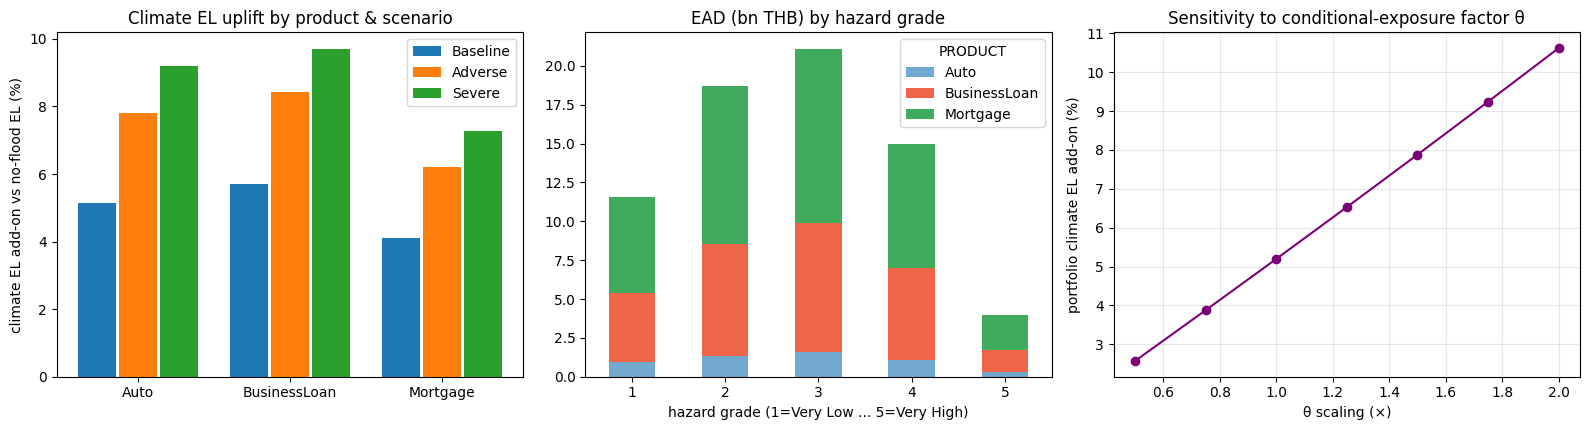

In [ ]:
# visual: climate EL add-on by product & scenario, EAD by hazard grade, theta sensitivity
fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

t = el_table("PRODUCT")
x = np.arange(len(t.index))
for i, s in enumerate(["BASELINE", "ADVERSE", "SEVERE"]):
    axes[0].bar(x + (i-1)*0.27, t[f"dEL_{s}_%"], width=0.25, label=s.title())
axes[0].set_xticks(x, t.index)
axes[0].set_ylabel("climate EL add-on vs no-flood EL (%)")
axes[0].set_title("Climate EL uplift by product & scenario")
axes[0].legend()

g_ead = port.groupby(["HAZARD_GRADE", "PRODUCT"])["EAD"].sum().unstack().fillna(0) / 1e9
g_ead.plot(kind="bar", stacked=True, ax=axes[1],
           color=["#74a9cf", "#ef6548", "#41ab5d"], rot=0)
axes[1].set_title("EAD (bn THB) by hazard grade")
axes[1].set_xlabel("hazard grade (1=Very Low ... 5=Very High)")

thetas = np.linspace(0.5, 2.0, 7)
sens = []
for tm in thetas:
    p_aff = port["P_EVENT"].clip(0, 1) * (port["THETA"] * tm).clip(0, 1)
    pd_s = port["PD_BASE"] * (1 + p_aff * (mult_g - 1))
    lgd_s = (port["LGD_BASE"] + (1 - port["LGD_BASE"]) * dmg_g * alpha * p_aff).clip(0, 0.95)
    sens.append((pd_s * lgd_s * port["EAD"]).sum() / port["EL_BASE"].sum() * 100 - 100)
axes[2].plot(thetas, sens, marker="o", color="#7a0177")
axes[2].set_xlabel("θ scaling (×)")
axes[2].set_ylabel("portfolio climate EL add-on (%)")
axes[2].set_title("Sensitivity to conditional-exposure factor θ")
axes[2].grid(alpha=0.3)

fig.tight_layout()
fig.savefig(OUT_DIR / "credit_impact_summary.png", dpi=130, bbox_inches="tight")
plt.show()

## 11. Risk mapping (LATLONG tambon centroids)

Two static maps (hazard landscape; portfolio climate-EL concentration) and one interactive
`flood_risk_map.html` with toggleable layers: hazard grades G3–G5 plus a portfolio layer per product
(circle size ∝ tambon EAD, popup shows EAD / ΔEL / grade).

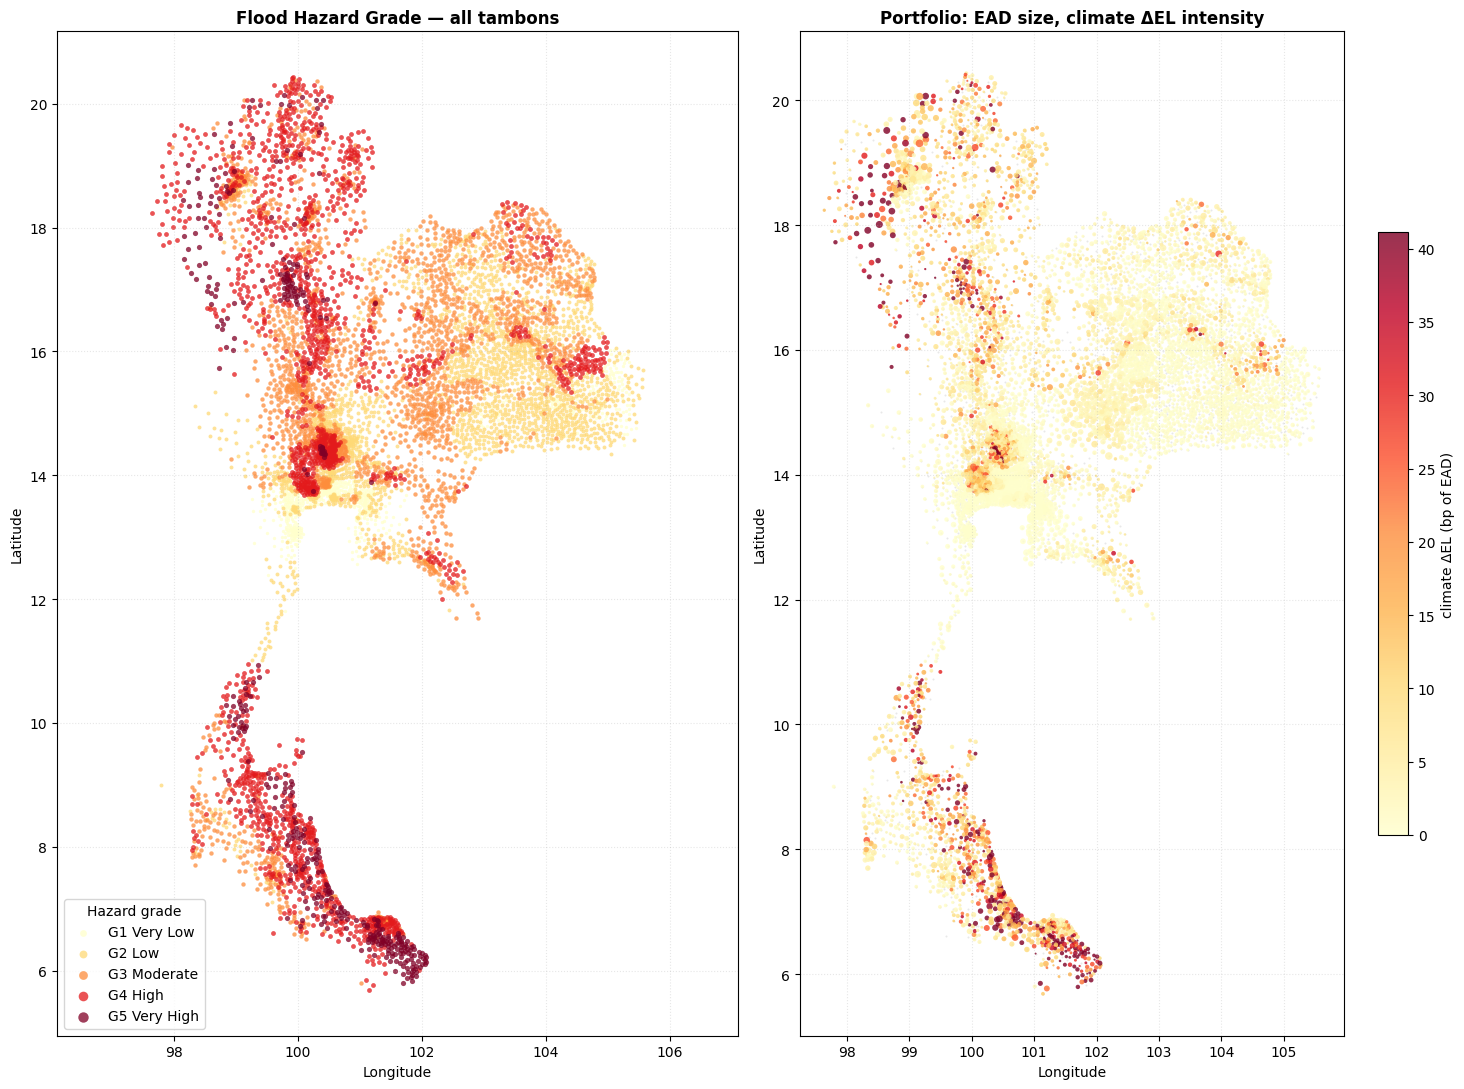

In [ ]:
GRADE_COLORS = {1: "#ffffcc", 2: "#fed976", 3: "#fd8d3c", 4: "#e31a1c", 5: "#800026"}
panel_xy = panel.merge(cen, on="GEOCODE", how="left").dropna(subset=["LAT", "LONG"])

fig, axes = plt.subplots(1, 2, figsize=(15, 11))
for g_, sub in panel_xy.groupby("HAZARD_GRADE"):
    axes[0].scatter(sub["LONG"], sub["LAT"], s=4 + g_*2, color=GRADE_COLORS[g_],
                    alpha=0.75, linewidths=0, label=f"G{g_} {GRADE_NAMES[g_]}")
axes[0].legend(loc="lower left", title="Hazard grade", markerscale=2)
axes[0].set_title("Flood Hazard Grade — all tambons", fontweight="bold")

tam_port = (port.groupby("GEOCODE")
                .agg(EAD=("EAD", "sum"), DELTA_EL=("DELTA_EL", "sum"),
                     GRADE=("HAZARD_GRADE", "max")).reset_index()
                .merge(cen, on="GEOCODE", how="left").dropna(subset=["LAT", "LONG"]))
axes[1].scatter(panel_xy["LONG"], panel_xy["LAT"], s=2, color="#e8e8e8", linewidths=0)
sc = axes[1].scatter(tam_port["LONG"], tam_port["LAT"],
                     s=np.sqrt(tam_port["EAD"]) / 280,
                     c=tam_port["DELTA_EL"] / tam_port["EAD"] * 1e4,
                     cmap="YlOrRd", alpha=0.8, linewidths=0,
                     vmax=np.percentile(tam_port["DELTA_EL"] / tam_port["EAD"] * 1e4, 97))
plt.colorbar(sc, ax=axes[1], shrink=0.6, label="climate ΔEL (bp of EAD)")
axes[1].set_title("Portfolio: EAD size, climate ΔEL intensity", fontweight="bold")

for ax in axes:
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude")
    ax.grid(alpha=0.3, ls=":")
fig.tight_layout()
fig.savefig(OUT_DIR / "risk_map_static.png", dpi=140, bbox_inches="tight")
plt.show()

In [ ]:
fmap = folium.Map(location=[13.5, 100.9], zoom_start=6, tiles="CartoDB positron")

# hazard layers G3-G5 (G1-G2 omitted to keep the HTML responsive)
for g_ in [3, 4, 5]:
    fg = folium.FeatureGroup(name=f"Hazard G{g_} ({GRADE_NAMES[g_]})", show=(g_ >= 4))
    for r in panel_xy[panel_xy["HAZARD_GRADE"] == g_].itertuples():
        folium.CircleMarker(
            location=[r.LAT, r.LONG], radius=2 + g_, color=GRADE_COLORS[g_],
            weight=0.5, fill=True, fill_color=GRADE_COLORS[g_], fill_opacity=0.75,
            popup=folium.Popup(
                f"<b>{r.TAMBON_E}</b> ({r.GEOCODE})<br>{r.AMPHOE_E}, {r.PROV_E}<br>"
                f"P(flood/yr)={r.P_EVENT:.2f} · severity={r.SEV_IDX:.2f}<br>"
                f"score={r.HAZARD_SCORE:.1f} → <b>G{r.HAZARD_GRADE} {GRADE_NAMES[r.HAZARD_GRADE]}</b>",
                max_width=240),
        ).add_to(fg)
    fg.add_to(fmap)

# portfolio layers: tambon-aggregated per product, hazard G3+ only
PROD_COLORS = {"Mortgage": "#1f78b4", "BusinessLoan": "#6a3d9a", "Auto": "#33a02c"}
tp = (port.groupby(["PRODUCT", "GEOCODE"])
          .agg(EAD=("EAD", "sum"), DELTA_EL=("DELTA_EL", "sum"), N=("LOAN_ID", "count"),
               GRADE=("HAZARD_GRADE", "max")).reset_index()
          .merge(cen, on="GEOCODE", how="left").dropna(subset=["LAT", "LONG"]))
tp = tp[tp["GRADE"] >= 3]
for prod, sub in tp.groupby("PRODUCT"):
    fg = folium.FeatureGroup(name=f"Portfolio {prod} (G3+ zones)", show=False)
    for r in sub.itertuples():
        folium.CircleMarker(
            location=[r.LAT, r.LONG], radius=float(np.clip(np.sqrt(r.EAD) / 1500, 2, 14)),
            color=PROD_COLORS[prod], weight=0.5, fill=True,
            fill_color=PROD_COLORS[prod], fill_opacity=0.6,
            popup=folium.Popup(
                f"<b>{prod}</b> · {r.N} loans · G{int(r.GRADE)}<br>"
                f"EAD {r.EAD/1e6:,.1f} MN THB<br>climate ΔEL {r.DELTA_EL/1e3:,.0f} k THB",
                max_width=220),
        ).add_to(fg)
    fg.add_to(fmap)

folium.LayerControl(collapsed=False).add_to(fmap)
legend = """<div style='position:fixed;bottom:24px;left:24px;z-index:9999;background:#fff;
padding:10px 12px;border:1px solid #888;border-radius:6px;font:12px sans-serif;'>
<b>Flood hazard grade</b><br>""" + "".join(
    f"<span style='display:inline-block;width:12px;height:12px;background:{GRADE_COLORS[g]};"
    f"border:1px solid #999;margin-right:6px;'></span>G{g} {GRADE_NAMES[g]}<br>" for g in [3, 4, 5]
) + "<i>portfolio layers: circle ∝ EAD</i></div>"
fmap.get_root().html.add_child(folium.Element(legend))

map_path = OUT_DIR / "flood_risk_map.html"
fmap.save(str(map_path))
print(f"interactive map -> {map_path}")
print(f"  hazard points G3-G5 : {len(panel_xy[panel_xy['HAZARD_GRADE'] >= 3]):,}")
print(f"  portfolio points    : {len(tp):,}")

interactive map -> /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/output/risk_model_20260610_223252/flood_risk_map.html
  hazard points G3-G5 : 4,643
  portfolio points    : 8,484


## 12. Exports

All result tables are written to the timestamped output folder for downstream reporting
(ICAAP / climate stress-testing packs, risk-appetite dashboards).

In [ ]:
# tambon-level hazard register
hazard_cols = ["GEOCODE", "TAMBON_E", "AMPHOE_E", "PROV_E", "REGION_E", "N_YEARS_FLOODED",
               "P_HIST", "FC_PROP", "P_EVENT", "AFF_HH_MEAN", "SEV_IDX",
               "HAZARD_SCORE", "HAZARD_GRADE"]
hazard_out = panel[hazard_cols].merge(cen, on="GEOCODE", how="left")
hazard_out.to_csv(OUT_DIR / "tambon_flood_hazard_scores.csv", index=False)

# loan-level results
loan_cols = ["LOAN_ID", "PRODUCT", "GEOCODE", "PROV_E", "REGION_E", "EAD",
             "PD_BASE", "LGD_BASE", "EL_BASE", "HAZARD_SCORE", "HAZARD_GRADE",
             "P_EVENT", "THETA",
             "PD_BASELINE", "LGD_BASELINE", "EL_BASELINE", "DELTA_EL",
             "EL_ADVERSE", "EL_SEVERE"]
port[loan_cols].to_csv(OUT_DIR / "portfolio_loan_level_results.csv", index=False)

# summary workbook
with pd.ExcelWriter(OUT_DIR / "flood_risk_summary.xlsx", engine="openpyxl") as xw:
    pd.DataFrame({"NOTE": [
        "Climate physical risk (flood) model - consumer credit portfolios, Thailand.",
        "Hazard: tambon-level annual flood probability (logistic model: forecast propensity, "
        "5-yr history, province prior, rainfall; validated on realized 2024 floods) x severity index.",
        "Grades: score=100*P_EVENT*(0.5+0.5*SEV_IDX); G1<5, G2 5-15, G3 15-30, G4 30-50, G5>=50.",
        "Portfolio: SYNTHETIC stand-in (seed=42) - replace with real loan tape keyed on GEOCODE.",
        "Credit translation: theta=0.10+0.30*SEV_IDX conditional-exposure factor; product damage "
        "matrices and PD multipliers per methodology section; EL'=PD'*LGD'*EAD.",
        "Scenarios: Baseline(1.0x,1.0x) Adverse(1.5x P_EVENT,1.25x damage) Severe(2.0x,1.5x).",
        f"Generated {TIMESTAMP} by flood_physical_risk_model.ipynb",
    ]}).to_excel(xw, sheet_name="ReadMe", index=False)
    el_table("PRODUCT").round(2).to_excel(xw, sheet_name="EL_by_Product")
    el_table("REGION_E").round(2).to_excel(xw, sheet_name="EL_by_Region")
    el_table("PROV_E").round(2).sort_values("EL_BASELINE_MN", ascending=False).to_excel(
        xw, sheet_name="EL_by_Province")
    el_table("HAZARD_GRADE").round(2).to_excel(xw, sheet_name="EL_by_HazardGrade")
    hazard_out.nlargest(300, "HAZARD_SCORE").to_excel(xw, sheet_name="Top300_Hazard_Tambons",
                                                      index=False)

print("written to", OUT_DIR)
for f in sorted(OUT_DIR.iterdir()):
    print(f"  {f.name:<42s} {f.stat().st_size/1e6:6.2f} MB")

written to /Users/kbstudio/Library/CloudStorage/OneDrive-Personal/Project/BAY/output/risk_model_20260610_223252
  credit_impact_summary.png                    0.08 MB
  eda_forecast_seasonality.png                 0.06 MB
  eda_historical_floods.png                    0.07 MB
  flood_risk_map.html                         14.70 MB
  flood_risk_summary.xlsx                      0.05 MB
  hazard_score_distribution.png                0.04 MB
  portfolio_loan_level_results.csv             8.62 MB
  risk_map_static.png                          0.88 MB
  tambon_flood_hazard_scores.csv               1.29 MB


## 13. Conclusions, limitations, next steps

### Key results (see tables/maps above)
- The 6-month flood forecast product carries real signal: the validation model reaches **AUC ≈ 0.81**
  against realized 2024 floods, with forecast propensity the strongest single predictor.
- Flood risk is structurally concentrated (North / Northeast / parts of the South and the Chao Phraya
  basin), and the portfolio's climate EL add-on differs materially by product — Business Loans carry the
  largest relative uplift (income disruption + contents damage), Autos the largest collateral-damage
  sensitivity, Mortgages the largest absolute EAD in flood zones.

### Limitations (read before using numbers)
1. **The portfolio is synthetic** — all EL figures are illustrative until the real loan tape is plugged into §9.
2. Damage matrices, PD multipliers and θ are **expert-judgment calibrations**, not estimated from claims/default
   data; the θ-sensitivity chart shows the EL add-on scales roughly linearly with it.
3. A tambon "event year" is a coarse hazard unit: no flood depth/duration; severity is proxied by affected
   households. 2563–2565 records lack impact data; severity there is median-imputed.
4. The validation is in-sample-by-period (2024) rather than walk-forward; with more years of forecast issues,
   re-validate annually.
5. Scenario multipliers are narrative placeholders — map them to BOT / NGFS scenario rainfall deltas when
   running formal climate stress tests.

### Next steps
1. Join the real loan tape on `GEOCODE` (collateral location for mortgage, registration/branch for auto,
   business address for SME) and re-run.
2. Calibrate damage matrices against historical post-flood default/LGD experience (e.g. 2011 floods, 2567 events).
3. Layer on transition-risk and rainfall-scenario projections; align scenarios to NGFS/BOT stress-test narratives.
4. Productionize: monthly refresh as each new forecast issue lands; track hazard-grade migrations as an
   early-warning indicator for collections and underwriting location policy.